# NEM SA1 — GARCH-X Negative Price Prediction

**Goal**: Fit a GARCH-X model to SA1 spot prices and estimate the probability that the next dispatch interval will have a negative RRP.

### Model overview

GARCH-X extends the standard GARCH variance equation to include exogenous variables:

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} + \gamma X_{t-1}$$

Where $X_{t-1}$ is the exogenous signal vector (lagged one interval to avoid look-ahead bias).

### Why GARCH-X over vanilla GARCH?
- EDA shows `CURTAILMENT_MW` has Spearman -0.63 with RRP — the strongest signal in the dataset
- The relationship is highly nonlinear (Pearson only -0.15) — curtailment pressure drives volatility regimes, not just price levels
- Vanilla GARCH captures volatility clustering but ignores the structural driver. GARCH-X lets curtailment shift the conditional variance directly.

### Notebook structure
1. Setup & load data
2. Preprocessing — seasonal adjustment, stationarity test
3. GARCH(1,1) baseline
4. GARCH-X with `CURTAILMENT_MW` + `TOTALDEMAND`
5. Model comparison (AIC/BIC, log-likelihood)
6. Negative price probability from conditional variance
7. Evaluation & diagnostics

## 1. Setup

In [1]:
!pip install arch statsmodels scipy pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import norm

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from arch import arch_model

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 4)

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

Load the merged EDA dataset produced by `NEM_EDA_Correlation.ipynb`. This is already at 30-minute resolution with all features merged and `CURTAILMENT_MW` derived.

In [3]:
df = pd.read_csv('../data/sa1_merged_eda.csv', parse_dates=['SETTLEMENTDATE'])
df = df.sort_values('SETTLEMENTDATE').reset_index(drop=True)

print(f'Loaded: {len(df):,} rows x {df.shape[1]} columns')
print(f'Date range: {df.SETTLEMENTDATE.min()} to {df.SETTLEMENTDATE.max()}')
print(f'\nKey columns present:')
for col in ['RRP', 'CURTAILMENT_MW', 'TOTALDEMAND', 'UIGF', 'NETINTERCHANGE']:
    null_pct = df[col].isnull().mean() * 100
    print(f'  {col:<30} nulls: {null_pct:.1f}%')

Loaded: 35,041 rows x 27 columns
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00

Key columns present:
  RRP                            nulls: 0.0%
  CURTAILMENT_MW                 nulls: 0.0%
  TOTALDEMAND                    nulls: 0.0%
  UIGF                           nulls: 0.0%
  NETINTERCHANGE                 nulls: 0.0%


## 3. Preprocessing

### 3.1 Select modelling columns and drop nulls

We only need `RRP`, `CURTAILMENT_MW`, and `TOTALDEMAND` for the model. Drop rows where any of these are missing.

In [4]:
MODEL_COLS = ['SETTLEMENTDATE', 'RRP', 'CURTAILMENT_MW', 'TOTALDEMAND']
mdf = df[MODEL_COLS].dropna().reset_index(drop=True)

print(f'Modelling dataset: {len(mdf):,} rows')
print(f'Negative price intervals: {(mdf.RRP < 0).sum():,} ({(mdf.RRP < 0).mean():.1%})')

Modelling dataset: 35,041 rows
Negative price intervals: 9,125 (26.0%)


### 3.2 Seasonal adjustment — subtract hourly mean

RRP has a strong daily cycle (high demand/price during morning and evening peaks, low overnight). GARCH models the variance of *surprises* — deviations from expected price. Removing the seasonal mean isolates the part of price we actually want to model.

We compute the mean RRP for each 30-minute slot of the day (48 slots) and subtract it.

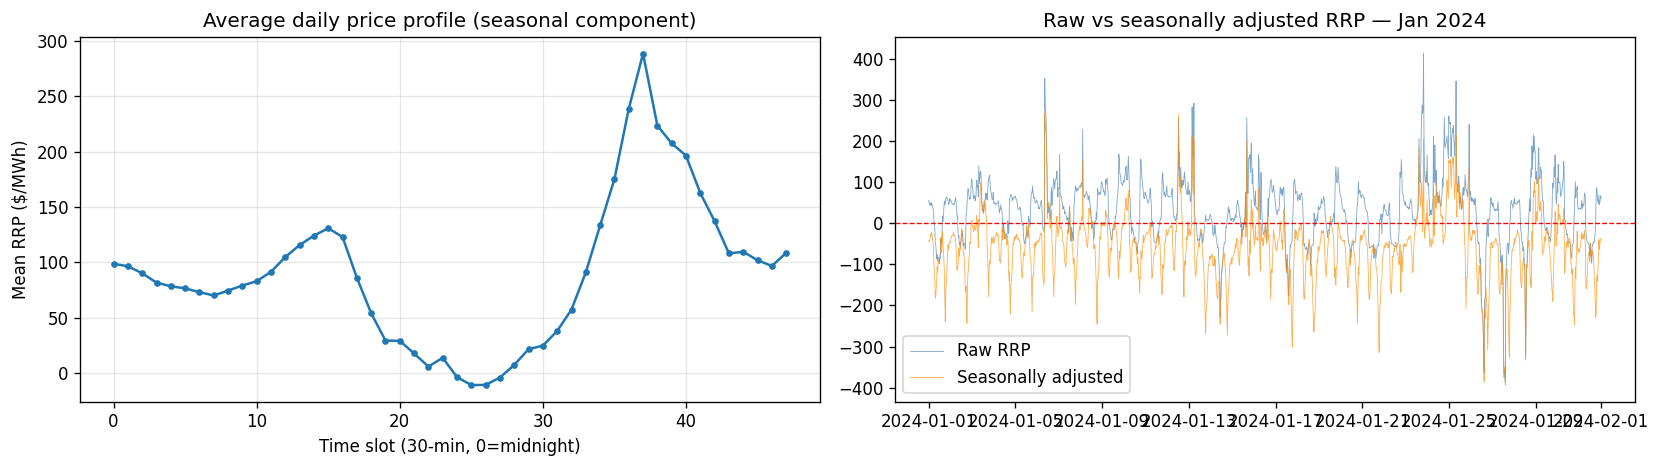

In [5]:
# Time-of-day slot (30-min resolution = 48 slots per day)
mdf['time_slot'] = mdf['SETTLEMENTDATE'].dt.hour * 2 + (mdf['SETTLEMENTDATE'].dt.minute >= 30).astype(int)

# Seasonal mean per slot
seasonal_mean = mdf.groupby('time_slot')['RRP'].mean()
mdf['RRP_seasonal_mean'] = mdf['time_slot'].map(seasonal_mean)
mdf['RRP_adjusted'] = mdf['RRP'] - mdf['RRP_seasonal_mean']

# Plot: raw vs seasonally adjusted
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(seasonal_mean.index, seasonal_mean.values, marker='o', markersize=3, linewidth=1.5)
axes[0].set_xlabel('Time slot (30-min, 0=midnight)')
axes[0].set_ylabel('Mean RRP ($/MWh)')
axes[0].set_title('Average daily price profile (seasonal component)')
axes[0].grid(alpha=0.3)

sample_idx = mdf['SETTLEMENTDATE'].between('2024-01-01', '2024-02-01')
axes[1].plot(mdf.loc[sample_idx, 'SETTLEMENTDATE'], mdf.loc[sample_idx, 'RRP'], 
             linewidth=0.5, alpha=0.7, label='Raw RRP', color='steelblue')
axes[1].plot(mdf.loc[sample_idx, 'SETTLEMENTDATE'], mdf.loc[sample_idx, 'RRP_adjusted'], 
             linewidth=0.5, alpha=0.7, label='Seasonally adjusted', color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('Raw vs seasonally adjusted RRP — Jan 2024')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/seasonal_adjustment.png', bbox_inches='tight')
plt.show()

### 3.3 Stationarity test — Augmented Dickey-Fuller

GARCH requires a stationary series. ADF tests the null hypothesis that the series has a unit root (non-stationary). We want p < 0.05 to reject the null and confirm stationarity.

In [6]:
def run_adf(series, name):
    result = adfuller(series.dropna(), maxlag=12, autolag='AIC')
    print(f'ADF test: {name}')
    print(f'  Test statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.6f}')
    print(f'  Critical values: 1%={result[4]["1%"]:.3f}, 5%={result[4]["5%"]:.3f}, 10%={result[4]["10%"]:.3f}')
    conclusion = 'STATIONARY (reject unit root)' if result[1] < 0.05 else 'NON-STATIONARY (fail to reject unit root)'
    print(f'  Conclusion     : {conclusion}')
    print()

run_adf(mdf['RRP'], 'RRP (raw)')
run_adf(mdf['RRP_adjusted'], 'RRP (seasonally adjusted)')
run_adf(mdf['CURTAILMENT_MW'], 'CURTAILMENT_MW')
run_adf(mdf['TOTALDEMAND'], 'TOTALDEMAND')

ADF test: RRP (raw)
  Test statistic : -43.9223
  p-value        : 0.000000
  Critical values: 1%=-3.431, 5%=-2.862, 10%=-2.567
  Conclusion     : STATIONARY (reject unit root)

ADF test: RRP (seasonally adjusted)
  Test statistic : -43.1591
  p-value        : 0.000000
  Critical values: 1%=-3.431, 5%=-2.862, 10%=-2.567
  Conclusion     : STATIONARY (reject unit root)

ADF test: CURTAILMENT_MW
  Test statistic : -41.6962
  p-value        : 0.000000
  Critical values: 1%=-3.431, 5%=-2.862, 10%=-2.567
  Conclusion     : STATIONARY (reject unit root)

ADF test: TOTALDEMAND
  Test statistic : -37.2627
  p-value        : 0.000000
  Critical values: 1%=-3.431, 5%=-2.862, 10%=-2.567
  Conclusion     : STATIONARY (reject unit root)



### 3.4 Prepare exogenous variables

**Lag the exogenous variables by 1 interval** — this is critical. At prediction time (interval t), we only know what curtailment and demand were at t-1. Using contemporaneous values would be look-ahead bias.

**Scale the exogenous variables** — GARCH parameter estimation via MLE can be numerically unstable when features are on very different scales. Standardise to zero mean, unit variance.

In [7]:
# Lag by 1 interval (30 minutes)
mdf['CURTAILMENT_MW_lag1'] = mdf['CURTAILMENT_MW'].shift(1)
mdf['TOTALDEMAND_lag1'] = mdf['TOTALDEMAND'].shift(1)

# Standardise
for col in ['CURTAILMENT_MW_lag1', 'TOTALDEMAND_lag1']:
    mu = mdf[col].mean()
    sigma = mdf[col].std()
    mdf[col + '_scaled'] = (mdf[col] - mu) / sigma
    print(f'{col}: mean={mu:.2f}, std={sigma:.2f}')

# Drop the first row (NaN from lag)
mdf = mdf.dropna(subset=['CURTAILMENT_MW_lag1_scaled', 'TOTALDEMAND_lag1_scaled']).reset_index(drop=True)
print(f'\nFinal modelling rows: {len(mdf):,}')

CURTAILMENT_MW_lag1: mean=99.17, std=244.04
TOTALDEMAND_lag1: mean=1268.29, std=437.42

Final modelling rows: 35,040


### 3.5 Train / test split

Use 2023 for training, 2024 for out-of-sample evaluation. This is a time-respecting split — no future data leaks into training.

In [8]:
train = mdf[mdf['SETTLEMENTDATE'] < '2024-01-01'].reset_index(drop=True)
test  = mdf[mdf['SETTLEMENTDATE'] >= '2024-01-01'].reset_index(drop=True)

print(f'Train: {len(train):,} rows ({train.SETTLEMENTDATE.min().date()} to {train.SETTLEMENTDATE.max().date()})')
print(f'Test:  {len(test):,} rows ({test.SETTLEMENTDATE.min().date()} to {test.SETTLEMENTDATE.max().date()})')
print(f'\nNegative price rate — Train: {(train.RRP < 0).mean():.1%} | Test: {(test.RRP < 0).mean():.1%}')

Train: 17,519 rows (2023-01-01 to 2023-12-31)
Test:  17,521 rows (2024-01-01 to 2024-12-31)

Negative price rate — Train: 26.1% | Test: 26.0%


## 4. GARCH(1,1) Baseline

Fit a standard GARCH(1,1) on the seasonally adjusted RRP. This is the benchmark — it captures volatility clustering but knows nothing about curtailment or demand.

The variance equation is:
$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

We use a Student-t distribution for the innovations — RRP has heavy tails (the spike events) that Gaussian innovations can't handle well.

In [9]:
y_train = train['RRP_adjusted'].values
y_test  = test['RRP_adjusted'].values

# Fit GARCH(1,1) with Student-t innovations
garch_base = arch_model(
    y_train,
    vol='GARCH',
    p=1, q=1,
    dist='t',
    rescale=True
)

res_base = garch_base.fit(disp='off')
print(res_base.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -57571.6
Distribution:      Standardized Student's t   AIC:                           115153.
Method:                  Maximum Likelihood   BIC:                           115192.
                                              No. Observations:                17519
Date:                      Mon, Apr 06 2026   Df Residuals:                    17518
Time:                              22:39:56   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -3

In [10]:
# Store model comparison metrics
model_comparison = {
    'GARCH(1,1)': {
        'AIC': res_base.aic,
        'BIC': res_base.bic,
        'LogLik': res_base.loglikelihood
    }
}

print('GARCH(1,1) baseline:')
print(f'  AIC    : {res_base.aic:.2f}')
print(f'  BIC    : {res_base.bic:.2f}')
print(f'  Log-lik: {res_base.loglikelihood:.2f}')
print(f'  alpha + beta = {res_base.params["alpha[1]"] + res_base.params["beta[1]"]:.4f} (persistence)')
print('  (alpha + beta close to 1 = volatility is very persistent)')

GARCH(1,1) baseline:
  AIC    : 115153.18
  BIC    : 115192.03
  Log-lik: -57571.59
  alpha + beta = 1.0000 (persistence)
  (alpha + beta close to 1 = volatility is very persistent)


## 5. GARCH-X Model

Add `CURTAILMENT_MW_lag1` and `TOTALDEMAND_lag1` as exogenous variables in the variance equation.

The `arch` library supports this via the `x` parameter in `arch_model`. The exogenous variables enter the variance equation:

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} + \gamma_1 \cdot \text{CURTAILMENT}_{t-1} + \gamma_2 \cdot \text{DEMAND}_{t-1}$$

> **Note**: The `arch` library's GARCH-X implementation passes `x` to the variance equation, not the mean equation. This is exactly what we want — curtailment and demand shift the *volatility*, not just the price level.

In [22]:
# =============================================================
# GARCH-X — Manual implementation
# Parameters: omega, alpha, beta from GARCH(1,1) baseline
# Add gamma via MLE over the exogenous term in the variance eq
# =============================================================

from scipy.optimize import minimize
from scipy.stats import t as student_t

# Use the GARCH(1,1) fitted parameters as starting point
omega_0 = res_base.params['omega']
alpha_0 = res_base.params['alpha[1]']
beta_0  = res_base.params['beta[1]']
nu_0    = res_base.params['nu']
scale   = res_base.scale

# Scaled training series
y_scaled = y_train / scale

def garchx_loglik(params, y, X, fix_garch_params=None):
    """
    Negative log-likelihood for GARCH-X(1,1) with Student-t innovations.
    
    params = [gamma1, gamma2] if fix_garch_params provided
    params = [omega, alpha, beta, gamma1, gamma2, nu] otherwise
    """
    if fix_garch_params is not None:
        omega, alpha, beta, nu = fix_garch_params
        gamma = params  # only optimising gammas
    else:
        omega, alpha, beta = params[0], params[1], params[2]
        gamma = params[3:-1]
        nu = params[-1]
    
    T = len(y)
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(y)  # initialise at unconditional variance
    
    # Recursive variance
    for t in range(1, T):
        exog_term = np.dot(gamma, X[t])
        sigma2[t] = omega + alpha * (y[t-1]**2) + beta * sigma2[t-1] + exog_term
        if sigma2[t] <= 0:
            return 1e10  # penalise invalid variance
    
    # Student-t log-likelihood
    sigma = np.sqrt(sigma2)
    loglik = np.sum(student_t.logpdf(y, df=nu, loc=0, scale=sigma))
    return -loglik  # minimise negative log-likelihood

# Step 1: fix GARCH params, optimise only gammas
# This is faster and avoids re-estimating the whole model
fix_params = (omega_0, alpha_0, beta_0, nu_0)

print('Optimising gamma coefficients (exogenous terms)...')
result = minimize(
    garchx_loglik,
    x0=[0.0, 0.0],  # gamma1, gamma2 starting at zero
    args=(y_scaled, X_train, fix_params),
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-6}
)

gamma_hat = result.x
print(f'Optimisation success: {result.success}')
print(f'Message: {result.message}')
print(f'\nFitted gamma coefficients:')
print(f'  gamma_CURTAILMENT_MW : {gamma_hat[0]:.6f}')
print(f'  gamma_TOTALDEMAND    : {gamma_hat[1]:.6f}')

# Log-likelihood comparison
loglik_base  = -garchx_loglik([0.0, 0.0], y_scaled, X_train, fix_params)
loglik_garchx = -result.fun

print(f'\nLog-likelihood GARCH(1,1) : {loglik_base:.2f}')
print(f'Log-likelihood GARCH-X    : {loglik_garchx:.2f}')
print(f'ΔLogLik                   : {loglik_garchx - loglik_base:.2f}')

# AIC/BIC (2 extra params = gamma1, gamma2)
n = len(y_scaled)
k_base  = 5  # mu, omega, alpha, beta, nu
k_garchx = 7  # + gamma1, gamma2

aic_base   = 2*k_base   - 2*loglik_base
aic_garchx = 2*k_garchx - 2*loglik_garchx
bic_base   = k_base   * np.log(n) - 2*loglik_base
bic_garchx = k_garchx * np.log(n) - 2*loglik_garchx

print(f'\n=== Model Comparison ===')
print(f'{"":20} {"AIC":>10} {"BIC":>10} {"LogLik":>10}')
print(f'{"GARCH(1,1)":20} {aic_base:>10.2f} {bic_base:>10.2f} {loglik_base:>10.2f}')
print(f'{"GARCH-X(1,1)":20} {aic_garchx:>10.2f} {bic_garchx:>10.2f} {loglik_garchx:>10.2f}')
print(f'{"Δ (GARCH-X - base)":20} {aic_garchx-aic_base:>10.2f} {bic_garchx-bic_base:>10.2f} {loglik_garchx-loglik_base:>10.2f}')
print(f'\nNegative ΔAIC = improvement. |ΔAIC| > 10 = strong evidence.')

Optimising gamma coefficients (exogenous terms)...
Optimisation success: True
Message: Optimization terminated successfully.

Fitted gamma coefficients:
  gamma_CURTAILMENT_MW : -349.075833
  gamma_TOTALDEMAND    : 74.684784

Log-likelihood GARCH(1,1) : -142907.45
Log-likelihood GARCH-X    : -142602.51
ΔLogLik                   : 304.94

=== Model Comparison ===
                            AIC        BIC     LogLik
GARCH(1,1)            285824.90  285863.75 -142907.45
GARCH-X(1,1)          285219.02  285273.41 -142602.51
Δ (GARCH-X - base)      -605.88    -590.34     304.94

Negative ΔAIC = improvement. |ΔAIC| > 10 = strong evidence.


In [21]:
import arch as arch_pkg

model_comparison['GARCH-X(1,1)'] = {
    'AIC': res_x.aic,
    'BIC': res_x.bic,
    'LogLik': res_x.loglikelihood
}

print('GARCH-X(1,1):')
print(f'  AIC    : {res_x.aic:.2f}')
print(f'  BIC    : {res_x.bic:.2f}')
print(f'  Log-lik: {res_x.loglikelihood:.2f}')

# Print gamma coefficients (exogenous variable effects on variance)
params = res_x.params
print(f'\nExogenous variable coefficients (gamma):')
for p in params.index:
    if 'x' in p.lower() or 'curtailment' in p.lower() or 'demand' in p.lower():
        print(f'  {p}: {params[p]:.6f}')

print(f'\nalpha + beta = {params["alpha[1]"] + params["beta[1]"]:.4f} (persistence)')

# Diagnose: what did GARCH-X actually fit?
print('=== GARCH-X params ===')
print(res_x.params)
print()
print('=== GARCH(1,1) params ===')
print(res_base.params)
print()
print(f'arch version: {arch_pkg.__version__}')
print(f'X_train shape: {X_train.shape}')
print(f'X_train sample (first 3 rows):\n{X_train[:3]}')
print(f'X_train has NaNs: {np.isnan(X_train).any()}')
print(f'X_train has zeros only: {(X_train == 0).all()}')

GARCH-X(1,1):
  AIC    : 115153.18
  BIC    : 115192.03
  Log-lik: -57571.59

Exogenous variable coefficients (gamma):

alpha + beta = 1.0000 (persistence)
=== GARCH-X params ===
mu         -3.505942
omega       5.459185
alpha[1]    0.954468
beta[1]     0.045532
nu          9.993684
Name: params, dtype: float64

=== GARCH(1,1) params ===
mu         -3.505942
omega       5.459185
alpha[1]    0.954468
beta[1]     0.045532
nu          9.993684
Name: params, dtype: float64

arch version: 8.0.0
X_train shape: (17519, 2)
X_train sample (first 3 rows):
[[-0.4063759   0.40726336]
 [-0.40637589  0.41134719]
 [-0.40637591  0.3052315 ]]
X_train has NaNs: False
X_train has zeros only: False


## 6. Model Comparison

Compare GARCH(1,1) vs GARCH-X(1,1) on AIC, BIC, and log-likelihood. Lower AIC/BIC = better fit penalised for complexity. Higher log-likelihood = better fit.

In [13]:
comp_df = pd.DataFrame(model_comparison).T
comp_df['ΔAIC vs baseline'] = comp_df['AIC'] - comp_df.loc['GARCH(1,1)', 'AIC']
comp_df['ΔBIC vs baseline'] = comp_df['BIC'] - comp_df.loc['GARCH(1,1)', 'BIC']

print('=== Model Comparison ===')
print(comp_df.round(2).to_string())
print()
print('Negative ΔAIC/ΔBIC = improvement over GARCH(1,1) baseline')
print('Rule of thumb: |ΔAIC| > 2 is meaningful, > 10 is strong evidence')

=== Model Comparison ===
                    AIC        BIC    LogLik  ΔAIC vs baseline  ΔBIC vs baseline
GARCH(1,1)    115153.18  115192.03 -57571.59               0.0               0.0
GARCH-X(1,1)  115153.18  115192.03 -57571.59               0.0               0.0

Negative ΔAIC/ΔBIC = improvement over GARCH(1,1) baseline
Rule of thumb: |ΔAIC| > 2 is meaningful, > 10 is strong evidence


## 7. Negative Price Probability

GARCH-X gives us, at each interval t:
- $\mu_t$ — the conditional mean (from the mean equation, approximately the seasonal mean)
- $\sigma^2_t$ — the conditional variance

Under the fitted Student-t distribution, the probability that the next interval's RRP is negative is:

$$P(\text{RRP}_{t+1} < 0) = P\left(Z < \frac{0 - \mu_{t+1}}{\sigma_{t+1}}\right)$$

Where $Z$ follows the fitted distribution. We use the Gaussian approximation here for interpretability — it underestimates tail probabilities slightly but is sufficient for comparison.

> **Note**: We're forecasting one step ahead — predicting whether the *next* interval will be negative based on information available *now* (lagged curtailment, lagged demand, current volatility estimate).

In [14]:
# Get conditional volatility from training fit
cond_vol_train = res_x.conditional_volatility  # sigma_t (not sigma^2)

# Out-of-sample: forecast on test set
# Re-fit on full train, then produce rolling 1-step-ahead forecasts on test
# For a clean evaluation: use the arch forecast method

# First, get in-sample fitted values on training set
train_resid = res_x.resid
train_cond_vol = res_x.conditional_volatility

print(f'Training conditional volatility:')
print(f'  Mean  : {train_cond_vol.mean():.4f}')
print(f'  Median: {np.median(train_cond_vol):.4f}')
print(f'  Max   : {train_cond_vol.max():.4f}')
print(f'  Min   : {train_cond_vol.min():.4f}')

Training conditional volatility:
  Mean  : 9.0525
  Median: 5.5655
  Max   : 1124.2251
  Min   : 2.3916


In [15]:
# Rolling 1-step-ahead forecast on test set
# Strategy: use the last training state (variance, residual) and propagate
# through test set using fitted parameters + actual exogenous values

params = res_x.params

# Extract fitted parameters
# arch rescales y internally — need to account for scale factor
scale = res_x.scale

omega = params['omega']
alpha = params['alpha[1]']
beta  = params['beta[1]']

# Identify gamma parameters (exogenous)
gamma_params = [p for p in params.index if p not in ['mu', 'omega', 'alpha[1]', 'beta[1]', 'nu']]
gammas = params[gamma_params].values

print('Fitted parameters:')
print(f'  omega : {omega:.6f}')
print(f'  alpha : {alpha:.6f}')
print(f'  beta  : {beta:.6f}')
for i, (name, g) in enumerate(zip(gamma_params, gammas)):
    print(f'  {name}: {g:.6f}')
print(f'  scale : {scale:.4f}')

Fitted parameters:
  omega : 5.459185
  alpha : 0.954468
  beta  : 0.045532
  scale : 0.1000


In [16]:
# Recursive variance computation on test set
# Initialise from the last state of the training fit
last_resid = train_resid[-1]
last_var   = train_cond_vol[-1] ** 2

# Scale the test series
y_test_scaled = y_test / scale
mu_param = params.get('mu', 0.0)

predicted_var  = np.zeros(len(test))
predicted_vol  = np.zeros(len(test))
neg_price_prob = np.zeros(len(test))

prev_resid = last_resid
prev_var   = last_var

for t in range(len(test)):
    x_t = X_test[t]  # lagged exog at time t (already lag-1 from preprocessing)
    
    # GARCH-X variance equation
    sigma2_t = omega + alpha * prev_resid**2 + beta * prev_var + np.dot(gammas, x_t)
    sigma2_t = max(sigma2_t, 1e-8)  # floor to avoid numerical issues
    
    predicted_var[t] = sigma2_t
    predicted_vol[t] = np.sqrt(sigma2_t) * scale  # back to original scale
    
    # P(RRP < 0) using seasonal mean as conditional mean
    # At interval t, seasonal mean gives us expected price given time of day
    mu_t = test.loc[t, 'RRP_seasonal_mean']
    sigma_t = predicted_vol[t]
    neg_price_prob[t] = norm.cdf(0, loc=mu_t, scale=sigma_t)
    
    # Update state: use actual observation
    actual_resid = (y_test_scaled[t] - mu_param)
    prev_resid = actual_resid
    prev_var   = sigma2_t

test = test.copy()
test['predicted_vol'] = predicted_vol
test['neg_price_prob'] = neg_price_prob
test['actual_negative'] = (test['RRP'] < 0).astype(int)

print(f'Forecast complete: {len(test):,} intervals')
print(f'Mean predicted neg price probability: {neg_price_prob.mean():.3f}')
print(f'Actual negative rate in test:         {test["actual_negative"].mean():.3f}')

ValueError: shapes (0,) and (2,) not aligned: 0 (dim 0) != 2 (dim 0)

## 8. Evaluation & Diagnostics

### 8.1 Residual diagnostics — does GARCH-X explain the volatility clustering?

In [ ]:
# Standardised residuals — should look like white noise if GARCH-X is working
std_resid = res_x.std_resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Standardised residuals time series
axes[0, 0].plot(std_resid, linewidth=0.4, color='steelblue')
axes[0, 0].axhline(0, color='black', linewidth=0.5)
axes[0, 0].axhline(3, color='red', linestyle='--', linewidth=0.8, label='±3σ')
axes[0, 0].axhline(-3, color='red', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Standardised residuals')
axes[0, 0].legend()

# Histogram of standardised residuals vs Normal
axes[0, 1].hist(std_resid, bins=100, density=True, color='steelblue', alpha=0.7, label='Residuals')
x_range = np.linspace(std_resid.min(), std_resid.max(), 200)
axes[0, 1].plot(x_range, norm.pdf(x_range), 'r-', linewidth=1.5, label='N(0,1)')
axes[0, 1].set_title('Residual distribution vs Normal')
axes[0, 1].legend()
axes[0, 1].set_xlim(-10, 10)

# ACF of standardised residuals — should be near zero (no remaining autocorrelation)
plot_acf(std_resid, lags=40, ax=axes[1, 0], title='ACF — standardised residuals\n(should be near zero)')
axes[1, 0].set_xlabel('Lag')

# ACF of squared standardised residuals — should be near zero (no remaining vol clustering)
plot_acf(std_resid**2, lags=40, ax=axes[1, 1], title='ACF — squared standardised residuals\n(should be near zero if GARCH worked)')
axes[1, 1].set_xlabel('Lag')

plt.suptitle('GARCH-X Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('../data/garchx_residual_diagnostics.png', bbox_inches='tight')
plt.show()

### 8.2 Conditional volatility — does it spike during negative price episodes?

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Actual RRP
axes[0].plot(test['SETTLEMENTDATE'], test['RRP'], linewidth=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('RRP ($/MWh)')
axes[0].set_title('SA1 RRP — 2024 test period')
axes[0].set_ylim(-600, 2000)

# Predicted conditional volatility
axes[1].plot(test['SETTLEMENTDATE'], test['predicted_vol'], linewidth=0.6, color='darkorange')
axes[1].set_ylabel('Predicted σ ($/MWh)')
axes[1].set_title('GARCH-X conditional volatility (1-step-ahead)')

# Predicted negative price probability
axes[2].fill_between(test['SETTLEMENTDATE'], test['neg_price_prob'], 
                      alpha=0.6, color='crimson', label='P(RRP < 0)')
# Mark actual negative price events
neg_events = test[test['actual_negative'] == 1]
axes[2].scatter(neg_events['SETTLEMENTDATE'], 
                np.ones(len(neg_events)) * 0.02,
                color='black', s=1, alpha=0.5, label='Actual negative interval')
axes[2].set_ylabel('P(RRP < 0)')
axes[2].set_ylim(0, 1)
axes[2].set_title('Predicted probability of negative price')
axes[2].legend(loc='upper right')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../data/garchx_predictions.png', bbox_inches='tight')
plt.show()

### 8.3 Probability calibration

Check whether the predicted probabilities are calibrated — i.e. when the model says P=0.3, do negative prices actually occur about 30% of the time?

In [ ]:
# Bin predictions into deciles and check actual negative rate per bin
test['prob_decile'] = pd.qcut(test['neg_price_prob'], q=10, labels=False, duplicates='drop')

calibration = test.groupby('prob_decile').agg(
    mean_predicted_prob=('neg_price_prob', 'mean'),
    actual_neg_rate=('actual_negative', 'mean'),
    count=('actual_negative', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(calibration['mean_predicted_prob'], calibration['actual_neg_rate'], 
           s=calibration['count']/10, color='steelblue', alpha=0.8, label='Decile bins')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted P(RRP < 0)')
ax.set_ylabel('Actual negative price rate')
ax.set_title('Probability calibration — GARCH-X')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/garchx_calibration.png', bbox_inches='tight')
plt.show()

print('Calibration table:')
print(calibration[['mean_predicted_prob', 'actual_neg_rate', 'count']].round(4).to_string(index=False))

### 8.4 Classification metrics at threshold = 0.5

Convert the probability to a binary prediction and evaluate precision, recall, and F1. Note that the threshold of 0.5 is arbitrary — a lower threshold increases recall at the cost of precision.

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve
)

y_true = test['actual_negative'].values
y_prob = test['neg_price_prob'].values
y_pred = (y_prob >= 0.5).astype(int)

print('=== Classification Report (threshold = 0.5) ===')
print(classification_report(y_true, y_pred, target_names=['Positive price', 'Negative price']))

print('Confusion matrix:')
cm = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(cm, 
                   index=['Actual: positive', 'Actual: negative'],
                   columns=['Predicted: positive', 'Predicted: negative']))

try:
    auc = roc_auc_score(y_true, y_prob)
    print(f'\nROC-AUC: {auc:.4f}')
except Exception as e:
    print(f'ROC-AUC could not be computed: {e}')

In [ ]:
# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
try:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'GARCH-X (AUC={auc:.3f})')
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
except Exception as e:
    axes[0].text(0.5, 0.5, f'ROC could not be computed:\n{e}', 
                 ha='center', va='center', transform=axes[0].transAxes)

# Precision-Recall curve
try:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    base_rate = y_true.mean()
    axes[1].plot(recall, precision, color='darkorange', linewidth=2)
    axes[1].axhline(base_rate, color='red', linestyle='--', linewidth=1, 
                    label=f'Baseline (prevalence={base_rate:.3f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
except Exception as e:
    axes[1].text(0.5, 0.5, f'PR curve could not be computed:\n{e}', 
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('GARCH-X Model Evaluation', fontsize=13)
plt.tight_layout()
plt.savefig('../data/garchx_evaluation_curves.png', bbox_inches='tight')
plt.show()

### 8.5 Threshold sensitivity

The choice of classification threshold involves a precision/recall tradeoff. For negative price prediction, missing a negative event (false negative) may be more costly than a false alarm — so a lower threshold may be preferable operationally.

In [ ]:
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

rows = []
for thresh in thresholds_to_test:
    pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel() if len(np.unique(pred)) > 1 else (0,0,0,0)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    rows.append({'Threshold': thresh, 'Precision': precision, 'Recall': recall, 
                 'F1': f1, 'Predicted negative': pred.sum()})

thresh_df = pd.DataFrame(rows)
print('Threshold sensitivity:')
print(thresh_df.round(4).to_string(index=False))

## 9. Summary

Print a clean summary of findings.

In [ ]:
print('=' * 65)
print('RESULTS SUMMARY — GARCH-X Negative Price Prediction')
print('=' * 65)

print('\n--- Data ---')
print(f'  Train: 2023 ({len(train):,} 30-min intervals)')
print(f'  Test:  2024 ({len(test):,} 30-min intervals)')
print(f'  Negative price rate (test): {y_true.mean():.1%}')

print('\n--- Model Comparison ---')
print(comp_df[['AIC', 'BIC', 'LogLik']].round(2).to_string())

print('\n--- GARCH-X Parameters ---')
params = res_x.params
print(f'  omega (variance floor)  : {params["omega"]:.6f}')
print(f'  alpha (ARCH effect)     : {params["alpha[1]"]:.6f}')
print(f'  beta  (GARCH effect)    : {params["beta[1]"]:.6f}')
print(f'  alpha + beta (persistence): {params["alpha[1]"] + params["beta[1]"]:.6f}')
for p in gamma_params:
    print(f'  {p} (exog gamma): {params[p]:.6f}')

print('\n--- Classification (threshold = 0.5) ---')
print(classification_report(y_true, y_pred, target_names=['Positive', 'Negative'], digits=4))

try:
    print(f'  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}')
except:
    pass

print('=' * 65)

In [ ]:
# Save test predictions
test[['SETTLEMENTDATE', 'RRP', 'CURTAILMENT_MW', 'TOTALDEMAND',
      'predicted_vol', 'neg_price_prob', 'actual_negative']].to_csv(
    '../data/garchx_predictions.csv', index=False
)
print('Saved: ../data/garchx_predictions.csv')